# Plot Results

Plot averaged **target / control accuracy** curves for the verification (`double_critic.j2`) and generation (`generative_response.j2`) prompts from
the inference / grading outputs produced by `main_vllm.py` and
`main_grading.py`.

The notebook has one section per phase. Each section has its own
configuration cell -- edit the variables marked `# EDIT:` and then run the cells.

| Section | Plots | Inputs to set |
| :--- | :--- | :--- |
| 1. Learn phase | LEARN-phase accuracy | `learn_experiment_group`, `learn_experiment_name`, `learn_api_grading` |
| 2. Update phase | LEARN + UPDATE overlay (split by a dotted line at the phase boundary) | `update_experiment_group`, `update_experiment_name`, `update_api_grading` (also requires Section 1 to have been run) |
| 3. Forget phase | LEARN + FORGET overlay (split by a dotted line at the phase boundary) | `forget_experiment_group`, `forget_experiment_name`, `forget_api_grading` (also requires Section 1 to have been run) |

The expected results layout is
`outputs/<experiment_group>/<experiment_name>/` -- i.e. the `output.experiment_group` / `output.experiment_name` produced by `main_vllm.py` (or `main_grading.py` for API grading; also set `*_api_grading=True`). For sweeps generated by `prepare_experiments.py`, `experiment_name` is the swept
hyperparameter folder (e.g. `learning_rate1e-05`); for non-sweep runs (only one experiment) it is `default`.

## Setup

In [ ]:
import os
import sys

import matplotlib.pyplot as plt

sys.path.append("../")

from origins.custom_classes import ExperimentResult, Phase
from origins.grading.stats import collect_stats
from origins.notebooks.utils_plot import (
    get_result_json_paths,
    plot_learn_forget_overlay,
    plot_learn_update_overlay,
    plot_phase_results,
)

%load_ext autoreload
%autoreload 2


def find_project_root(marker: str = ".git") -> str | None:
    path = os.getcwd()
    while path != os.path.dirname(path):
        if marker in os.listdir(path):
            return path
        path = os.path.dirname(path)
    return None


root = find_project_root()
if root is not None:
    os.chdir(root)
print("Working directory:", os.getcwd())


def load_summary_stats(experiment_group, experiment_name, *, exp_dir="outputs", api_grading=False):
    """Locate results under outputs/<experiment_group>/<experiment_name> and run collect_stats."""
    results_path = get_result_json_paths(exp_dir, experiment_group, experiment_name, verbose=False)
    if not results_path:
        raise ValueError(
            f"No result files found (tried results.json, rank shards, and per-epoch "
            f"graded files) for: {experiment_group}/{experiment_name}"
        )
    if isinstance(results_path, ExperimentResult):
        print(f"[{experiment_group}/{experiment_name}] in-memory merged ExperimentResult")
        kwargs = {"experiment_results": results_path}
    else:
        print(f"[{experiment_group}/{experiment_name}] {results_path}")
        kwargs = {"filepath": results_path}
    summary_stats = collect_stats(
        **kwargs, collect_raw=True, verbosity=0, api_grading=api_grading,
    )
    print(f"  Loaded {len(summary_stats)} iteration(s): {sorted(summary_stats.keys())}")
    return summary_stats

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Working directory: /claire-rcp-scratch/home/surina/factgap/run


## Section 1: Learn phase

Plot the averaged target / control accuracy for a learn-phase run. Top panel is verification (`double_critic.j2`), bottom panel is generation (`generative_response.j2`).

**Run this section first** -- both Section 2 (update) and Section 3
(forget) reuse `learn_summary_stats` to draw the LEARN-phase curves before
the phase boundary.

In the next cell, set:

- `learn_experiment_group` -- the `output.experiment_group` of the learn
  run (e.g. `learn_gemma3_4b_infer` for inference-only outputs, or
  `learn_gemma3_4b_grade` for API-graded outputs).
- `learn_experiment_name` -- the `output.experiment_name` (sub-folder
  under `<experiment_group>`), e.g. `default`, or `learning_rate1e-05`
  for a swept run.
- `learn_api_grading` -- `True` if the run was graded by `main_grading.py`
  (i.e. `learn_experiment_group` ends in `_grade`), `False` for raw
  `main_vllm.py` outputs.

In [ ]:
exp_dir = "outputs"  # EDIT: top-level outputs directory (if changed from default path)

learn_experiment_group = "learn_gemma3_4b_infer"  # EDIT: <experiment_group> of the learn run
learn_experiment_name = "default"                 # EDIT: <experiment_name> (sub-folder under <experiment_group>)
learn_api_grading = False                         # EDIT: True if loading API graded results

_learn_path = os.path.join(exp_dir, learn_experiment_group)
print("Experiment folder:", _learn_path)
if not os.path.isdir(_learn_path):
    print("(experiment folder not found)")

learn_summary_stats = load_summary_stats(
    learn_experiment_group,
    learn_experiment_name,
    exp_dir=exp_dir,
    api_grading=learn_api_grading,
)

Experiment folder: outputs/learn_gemma3_4b_infer


[learn_gemma3_4b_infer/default] in-memory merged ExperimentResult
  Loaded 21 iteration(s): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]


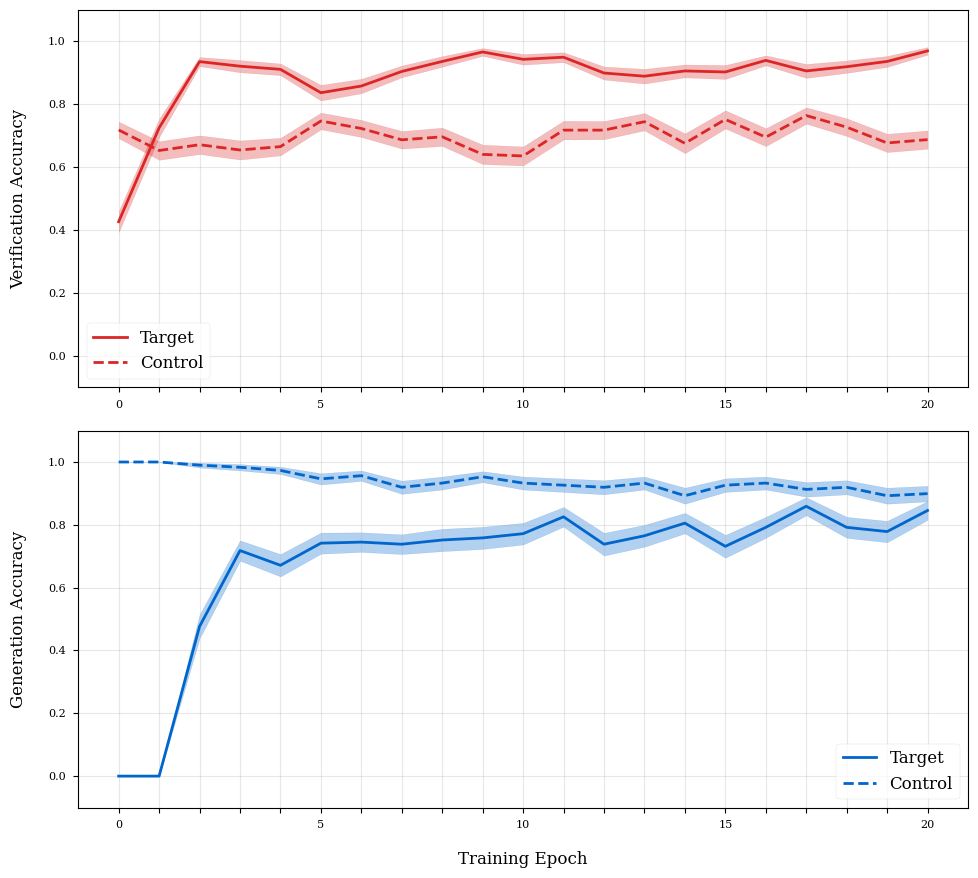

In [ ]:
fig = plot_phase_results(
    learn_summary_stats,
    phase=Phase.LEARN.value,
    use_api_grading=learn_api_grading,
)
plt.show()

### Variant: plot API-graded learn-phase results

The same loader and plotter handle outputs produced by `main_grading.py`.
Compared to the inference plot above, three things change:

1. point `learn_grade_experiment_group` at the `*_grade` folder instead of the `*_infer` folder,
2. pass `api_grading=True` to `load_summary_stats` (so it reads the per-epoch `graded_*.json` files), and
3. pass `use_api_grading=True` to `plot_phase_results` (so labels and metric selection match the graded format).

Everything else — `experiment_name`, project layout, plotting helpers — is identical. The cell below is the API-graded equivalent of Section 1, written to a separate variable (`learn_graded_summary_stats`) so it does not clobber `learn_summary_stats`, which the overlay sections still use.

Experiment folder: outputs/learn_gemma3_4b_grade
[learn_gemma3_4b_grade/default] in-memory merged ExperimentResult
Warning [iteration 0]: 1587/2372 entries (66.9%) are missing API grading verdicts and were skipped for API metrics.
Warning [iteration 1]: 1587/2372 entries (66.9%) are missing API grading verdicts and were skipped for API metrics.
Warning [iteration 2]: 1587/2372 entries (66.9%) are missing API grading verdicts and were skipped for API metrics.
Warning [iteration 3]: 1587/2372 entries (66.9%) are missing API grading verdicts and were skipped for API metrics.
Warning [iteration 4]: 1587/2372 entries (66.9%) are missing API grading verdicts and were skipped for API metrics.
Warning [iteration 5]: 1587/2372 entries (66.9%) are missing API grading verdicts and were skipped for API metrics.
Warning [iteration 6]: 1587/2372 entries (66.9%) are missing API grading verdicts and were skipped for API metrics.
Warning [iteration 7]: 1587/2372 entries (66.9%) are missing API grading 

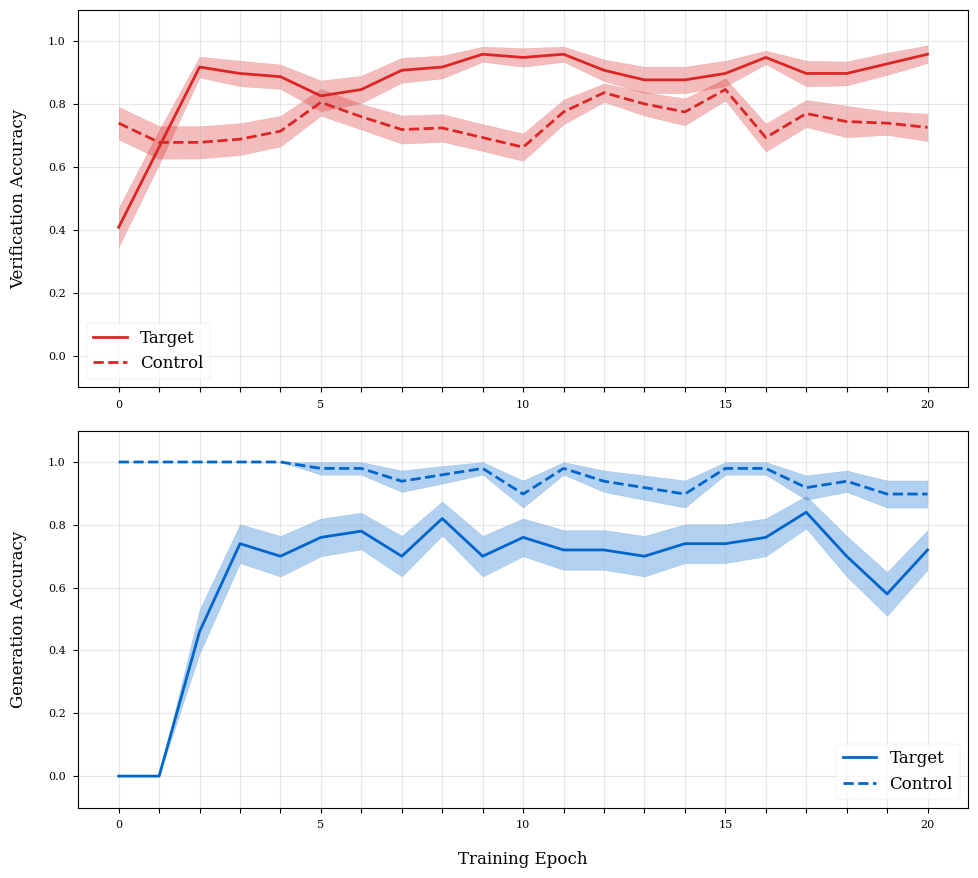

In [ ]:
learn_experiment_group = "learn_gemma3_4b_grade"  # EDIT: <experiment_group> of the API-graded run
learn_experiment_name = "default"                 # EDIT: <experiment_name> (sub-folder under <experiment_group>)

_learn_grade_path = os.path.join(exp_dir, learn_experiment_group)
print("Experiment folder:", _learn_grade_path)
if not os.path.isdir(_learn_grade_path):
    print("(experiment folder not found)")

learn_summary_stats = load_summary_stats(
    learn_experiment_group,
    learn_experiment_name,
    exp_dir=exp_dir,
    api_grading=True,
)

fig = plot_phase_results(
    learn_summary_stats,
    phase=Phase.LEARN.value,
    use_api_grading=True,
)
plt.show()

## Section 2: Update phase (LEARN + UPDATE overlay)

Plot both the LEARN- and UPDATE-phase curves on the same axes per template. The LEARN-phase curves are cropped at the phase boundary so they sit
side-by-side with the UPDATE-phase curves; a dotted vertical line marks the transition (the first UPDATE-phase iteration).

**Prerequisite:** Section 1 must have been run already so that `learn_summary_stats` is in scope. The LEARN run pointed to in Section 1
should be the same one that the UPDATE run was continued from (`_learn_config` / `_learn_run_name` in the update sweep YAML).

In the next cell, set:

- `update_experiment_group` -- the `output.experiment_group` of the update
  run (e.g. `update_gemma3_4b_infer` or `update_gemma3_4b_grade`).
- `update_experiment_name` -- the `output.experiment_name` (sub-folder
  under `<experiment_group>`), e.g. `default` or `learning_rate4e-06`.
- `update_api_grading` -- `True` if loading API graded results

In [ ]:
update_experiment_group = "update_gemma3_4b_infer"  # EDIT: <experiment_group> of the update run
update_experiment_name = "default"                  # EDIT: <experiment_name> (sub-folder under <experiment_group>)
update_api_grading = False                          # EDIT: True if loading API graded results

_update_path = os.path.join(exp_dir, update_experiment_group)
print("Experiment folder:", _update_path)
if not os.path.isdir(_update_path):
    print("(experiment folder not found)")

update_summary_stats = load_summary_stats(
    update_experiment_group,
    update_experiment_name,
    exp_dir=exp_dir,
    api_grading=update_api_grading,
)

Experiment folder: outputs/update_gemma3_4b_infer


[update_gemma3_4b_infer/default] in-memory merged ExperimentResult
  Loaded 21 iteration(s): [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]


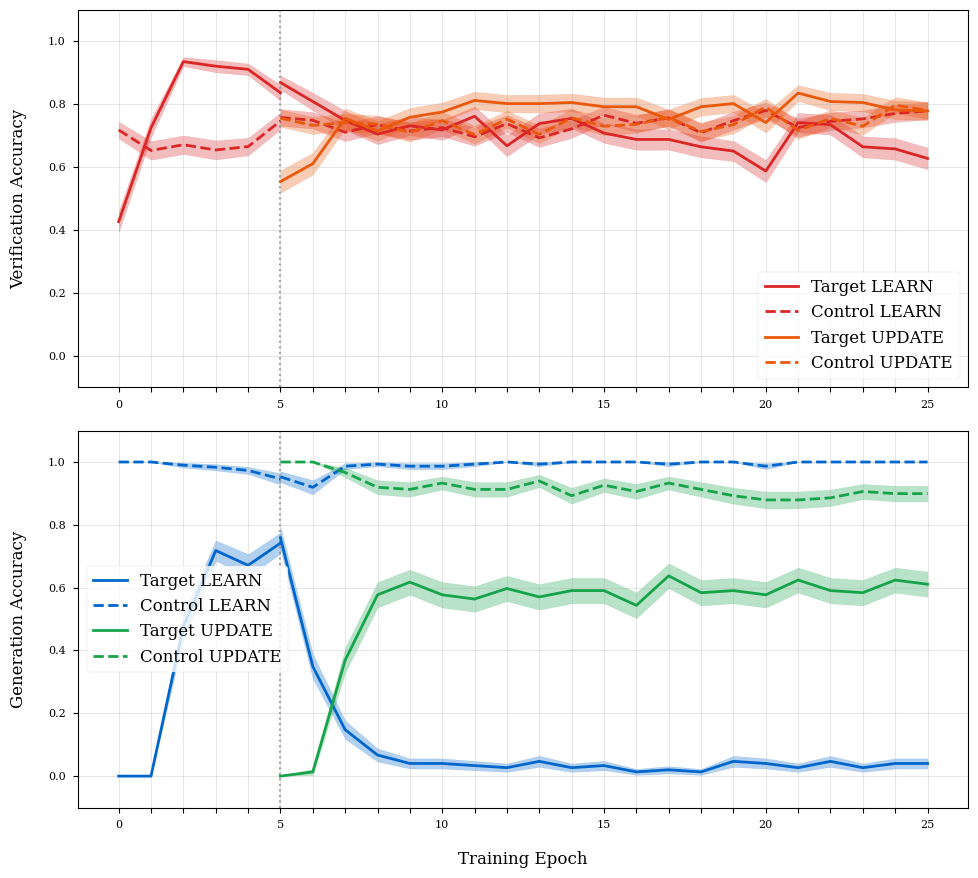

In [ ]:
fig = plot_learn_update_overlay(
    update_summary_stats,
    learn_summary_stats=learn_summary_stats,
    use_api_grading=update_api_grading,
)
plt.show()

## Section 3: Forget phase (LEARN + FORGET overlay)

Plot LEARN-phase accuracy on the LEARN checkpoints alongside LEARN-phase accuracy on the FORGET checkpoints. The plot shows two segments, joined at the forget boundary (dotted vertical line):

- LEARN on LEARN checkpoints, in the same red/blue hues as Section 1, for
  iterations up to the boundary;
- LEARN on FORGET checkpoints, in violet (verification) / cyan
  (generation), for iterations from the boundary onward.

**Prerequisite:** Section 1 must have been run already so that `learn_summary_stats` is in scope. The LEARN run pointed to in Section 1 should be the same one that the FORGET run was continued from (`_learn_config` / `_learn_run_name` in the forget sweep YAML).

In the next cell, set:

- `forget_experiment_group` -- the `output.experiment_group` of the
  forget inference run (e.g. `forget_gemma3_4b_epoch0_infer` for the
  inference-only outputs).
- `forget_experiment_name` -- the `output.experiment_name` (sub-folder
  under `<experiment_group>`), as in Section 1.
- `forget_api_grading` -- `True` if loading API graded results

In [ ]:
forget_experiment_group = "forget_gemma3_4b_epoch0_infer"  # EDIT: <experiment_group> of the forget run
forget_experiment_name = "default"                         # EDIT: <experiment_name> (sub-folder under <experiment_group>)
forget_api_grading = False                                 # EDIT: True if loading API graded results

_forget_path = os.path.join(exp_dir, forget_experiment_group)
print("Experiment folder:", _forget_path)
if not os.path.isdir(_forget_path):
    print("(experiment folder not found)")

forget_summary_stats = load_summary_stats(
    forget_experiment_group,
    forget_experiment_name,
    exp_dir=exp_dir,
    api_grading=forget_api_grading,
)


Experiment folder: outputs/forget_gemma3_4b_epoch0_infer
[forget_gemma3_4b_epoch0_infer/default] in-memory merged ExperimentResult
  Loaded 31 iteration(s): [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35]


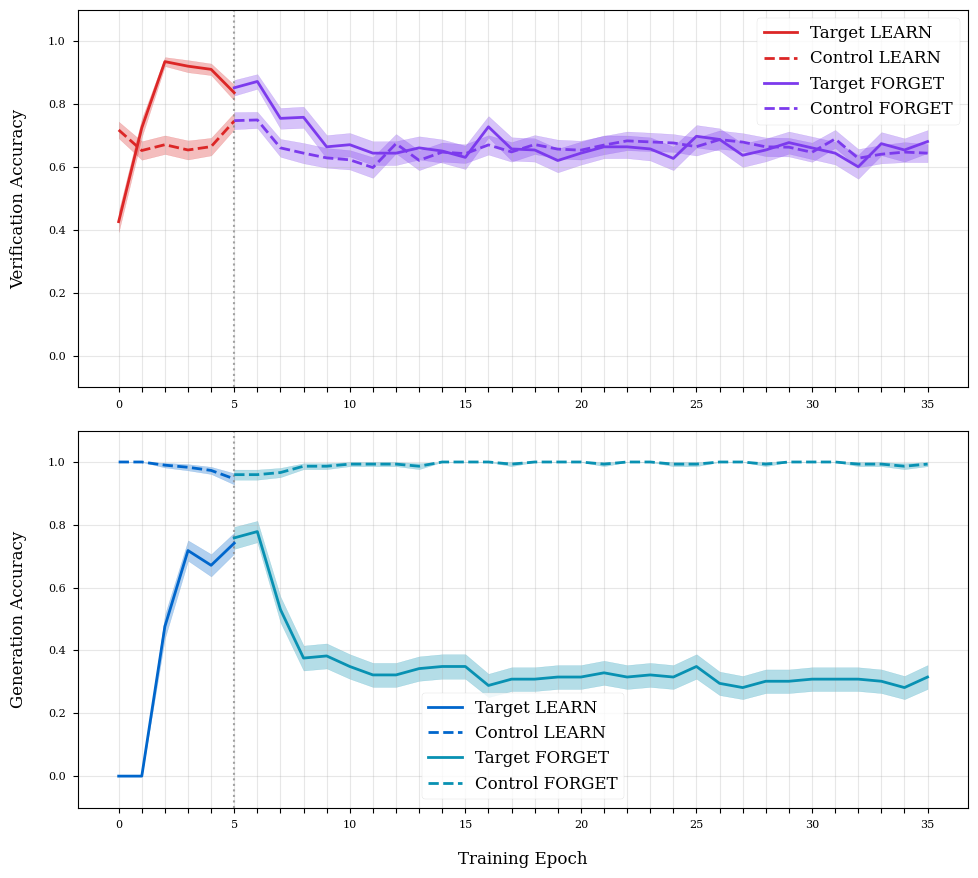

In [ ]:
fig = plot_learn_forget_overlay(
    forget_summary_stats,
    learn_summary_stats=learn_summary_stats,
    use_api_grading=forget_api_grading,
)
plt.show()
